In [1]:
# 실제로 코딩하며 랭그래프의 차이를 직접 경험해 봅시다. 사용자와 대화를 주고받는 단순한 구조의 챗봇을 만들겠습니다. 
# 이 예제로는 랭그래프의 장점을 제대로 느끼기 어렵겠지만 랭그래프의 기본 구조를 이해하는 데 도움될 것입니다. 
# 12-3절과 그 이후 실습에서 랭그래프의 기능을 점점 더 확장해 보겠습니다.

# ★ 이번 실습에서 사용하는 예제 코드는 랭그래프 공식문서인 
# LangGraph Quick Start(https://langchainai.github.io/langgraph/tutorials/introduction/)
# 의 내용을 참고했습니다.

# (venv) PS C:\Aiprojects> deactivate
# PS C:\Aiprojects> python -m venv ch12_env
# PS C:\Aiprojects> ch12_env\Scripts\activate  
# (ch12_env) PS C:\Aiprojects> 

# python.exe -m pip install --upgrade pip
# pip uninstall -y langchain langchain-core langgraph langgraph-checkpoint langgraph-sdk langsmith
# pip uninstall -y langchain-community langchain-text-splitters
# pip install langgraph==0.2.74 langchain-core==0.3.35 langchain-openai==0.2.7 langgraph-checkpoint==2.0.16 langgraph-sdk==0.1.53 langsmith==0.3.8 openai==1.54.0 pydantic==2.10.6 httpx==0.27 tiktoken==0.12.0

# 커널 연결 후 진행한다.

from langchain_openai import ChatOpenAI
# 모델 초기화


model = ChatOpenAI(model="gpt-4o-mini")
model.invoke('안녕하세요!')

AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 10, 'total_tokens': 20, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a7190374f3', 'finish_reason': 'stop', 'logprobs': None}, id='run-7de0ac17-2df1-470d-9767-c84f30c14182-0', usage_metadata={'input_tokens': 10, 'output_tokens': 10, 'total_tokens': 20, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [ ]:
# 랭그래프에서 상태는 언어 모델이 임무를 수행하면서 현재 상태를 명확히 관리할 수 있도록
# 돕는 요소입니다. 랭그래프는 여러 노드, 즉 AI 에이전트가 각자 맡은 일을 수행하도록 구성
# 되고 이 노드들은 상황에 맞게 작업할 수 있도록 필요한 정보를 주고받아야 합니다.
# 일반적으로 랭그래프에서는 State(상태) 클래스에 필요한 데이터 형식을 최대한 명확하게 정
# 의합니다. 이렇게 정의된 상태에 각 노드에서 처리된 결과를 저장하고 이 정보를 다음 작업을
# 수행할 노드로 전달합니다. 이처럼 랭그래프에서는 각 작업을 진행하는 데 필요한 항목들의
# 자료 형태를 상태에 미리 정해 놓아야 각 노드가 필요한 정보를 정확히 받아 작업이 순차로 잘
# 이어집니다.

# 이전 실습에서 만든 챗봇에 State 클래스와 그래프를 생성해 보겠습니다.
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):	
# State 클래스는 TypedDict를 사용하여 딕셔너리 형태로 관리됩니다.
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
        messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다.   
        # add_messages 함수를 추가합니다. add_messages 함수는 langgraph에서 제공하는 함수로 문자열이 주어질 때 이를 추가하는 기능을 합니다.
       'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.  
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다)
    """
    messages: Annotated[list[str], add_messages]	# State 클래스에는 messages라는 변수만 포함되어 있으며, 이 변수는 Annotated를 사용해 문자열로 구성된 리스트 형식임을 명시합니다.

# StateGraph 클래스를 사용하여 State 타입의 그래프를 생성합니다.
graph_builder = StateGraph(State) # 생성한 State를 이용해 StateGraph를 만들어 graph_builder라는 변수에 담습니다.

In [ ]:
# 노드 생성하기

# 노드를 설정할 차례입니다. 앞서 설명했듯이 랭그래프는 각 노드에서 처리한 결과를 상태에
# 서 관리하고, 각 노드를 엣지로 연결하는 그래프 형태로 표현하여 대화나 데이터 흐름을 관리
# 합니다. 여기서 노드는 그래프의 한 지점을 의미하며 하나의 단계를 표현한다고 이해하면 쉽
# 습니다.
# 사용자가 질문하면 답변을 생성하는 generate라는 노드를 가진 랭그래프를 만들겠습니다.
# 이 노드는 기존의 대화 내용에 기반하여 GPT로 답변을 생성하는 역할을 합니다.

In [3]:
def generate(state: State):	# generate 함수를 만듭니다. 매개변수는 앞서 정의한 State를 받도록 설정합니다.
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.
		
    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리. 
          형식은 {"messages": [응답 메시지]}입니다.
    """ 
    return {"messages": [model.invoke(state["messages"])]}	
    # state 안에는 messages라는 리스트룰 담을 수 있는 변수만 포함되어 었습니다. 이 노드는 GPT 모델에
    # state["messages"]를 전달하여 답변을 받아 온 뒤 그 결과를 딕셔너리 형태로 반환하는 간단한 역할을 합니다.

graph_builder.add_node("generate", generate)	
# 마지막으로 앞서 만든 graph_bui lder에 generate 노드를 추가합니다. 이때 노드의 이름과 그 해당 함수명을 함께 넣어 줍니다.

In [4]:
# 엣지 설정하기
# 그래프는 노드와 엣지로 구성됩니다. 이번 예제에서는 노드 앞뒤로 START와 END 노드를 지정하고 엣지를 설정해 보겠습니다. START와 END는 랭그래프에서 제공하는 노드입니다.

# 1. 앞서 만든 graph_builder에 연결 관계를 선언합니다. 그래프는 START에서 챗봇을 거쳐 END로 가는 흐름으로 구성됩니다. 
# 이 흐름을 정의하고 그래프를 컴파일하여 graph로 선언합니다

graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", END)    

graph = graph_builder.compile()

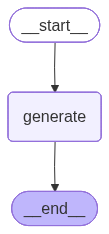

In [5]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception: 
    pass

In [6]:
# 그래프를 이용해 답변을 생성하기 위해 "messages"의 리스트에 문장을 넣습니다. 그리고 graph.invoke()의 결과 데이터 타입과 전체 response를 확인하는 코드를 작성합니다.

# 이 셀을 실행해 보면 데이터가 AddableValuesDict 형태로 반환된 것을 알 수 있습니다. 
# 이때 사용자가 입력한 문장이 담긴 리스트에 GPT의 답변이 추가된 상태로 결과가 반환됩니다. 
# 이런 결과가 나온 이유는 State를 정의할 때 messages에 add_messages를 추가했기 때문입니다. 
# 이렇게 설정한 덕분에 새로 입력된 메시지가 기존 메시지 리스트에 덧붙여지는 방식으로 동작합니다.

response = graph.invoke({"messages": ["안녕하세요! 저는 김기원입니다"]})

print(type(response))
response

<class 'langgraph.pregel.io.AddableValuesDict'>


{'messages': [HumanMessage(content='안녕하세요! 저는 김기원입니다', additional_kwargs={}, response_metadata={}, id='e555d32f-b307-46dd-a613-3c6092b6518d'),
  AIMessage(content='안녕하세요, 김기원님! 만나서 반갑습니다. 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 15, 'total_tokens': 36, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_77c1b30b18', 'finish_reason': 'stop', 'logprobs': None}, id='run-6786e2c5-ad4b-42e5-a62e-d09737d687ba-0', usage_metadata={'input_tokens': 15, 'output_tokens': 21, 'total_tokens': 36, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [ ]:
response["messages"].append("제 이름을 아시나요?")
graph.invoke(response)

# 단순한 챗봇을 만드는데 왜 이렇게 복잡하게 구성해야 하는지 의문이 생길 수 있습니다. 
# 하지만 랭그래프 방식으로 구성하면 앞으로 언어 모델에게 더 복잡한 작업을 맡길 때 확장하기 쉽고 명확해집니다.

{'messages': [HumanMessage(content='안녕하세요! 저는 김기원입니다', additional_kwargs={}, response_metadata={}, id='e555d32f-b307-46dd-a613-3c6092b6518d'),
  AIMessage(content='안녕하세요, 김기원님! 만나서 반갑습니다. 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 15, 'total_tokens': 36, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_77c1b30b18', 'finish_reason': 'stop', 'logprobs': None}, id='run-6786e2c5-ad4b-42e5-a62e-d09737d687ba-0', usage_metadata={'input_tokens': 15, 'output_tokens': 21, 'total_tokens': 36, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}),
  HumanMessage(content='제 이름을 아시나요?', additional_kwargs={}, response_metadata={}, id='5b25d61f-

In [ ]:
# 스트림 출력하기
# 언어 모델의 반응 속도를 크게 신경 쓰지 않아도 되는 문서 생성 작업에서는 현재 방식을 사용해도 아무 문제가 없습니다. 
# 하지만 챗봇을 만들려면 사용자의 질문에 최대한 빠르게 반응할 수 있도록 스트림 방식으로 출력해야 합니다. 이전 파일에 이어서 코드를 작성해 보겠습니다.

# 스트림 방식으로 출력할 때에는 .invoke 대신 .stream을 사용합니다. 이때 stream_mode를 messages로 선택하면 메시지를 스트림 방식으로 실시간 출력합니다.

# messages : 메시지를 스트림 방식으로 실시간 출력합니다.
# values : 랭그래프의 단계별로 상태가 어떻게 변하는지 파악할 때 사용합니다.
# updates : 단계별로 변경된 내용만 반환합니다.
# debug : 디버깅용 옵션으로 실행되는 과정의 정보를 자세히 제공합니다.
# custom : 사용자 정의 방식으로 스트림을 설정할 수 있습니다.

inputs = {"messages": [("human", "한국과 일본의 관계에 대해 자세히 알려줘")]}
for chunk, _ in graph.stream(inputs, stream_mode="messages"):
    print(chunk.content, end="")

한국과 일본의 관계는 역사적으로 복잡하고 다층적입니다. 두 나라는 지리적으로 가까운 이웃이지만, 역사적 사건들이 그 관계에 많은 영향을 미쳤습니다. 다음은 한국과 일본의 관계에 대한 주요 사항들입니다.

### 역사적 배경

1. **고대 및 중세**: 한국과 일본은 고대부터 문화적, 경제적 교류가 있었습니다. 그러나 일본의 여러 왕조가 한국의 여러 왕국에 영향을 받기도 했습니다. 특히, 신라와 백제의 문화가 일본에 전파된 경우가 많습니다.

2. **일제 강점기 (1910-1945)**: 한국은 1910년부터 1945년까지 일본의 식민지로 지배받았습니다. 이 시기에 많은 한국인들이 강제로 동원되었고, 문화와 언어가 억압당했습니다. 이러한 경험은 한국인들에게 깊은 상처로 남아 있으며, 일본에 대한 반감으로 이어졌습니다.

3. **전후 관계**: 제2차 세계대전 이후, 한국은 1945년에 해방되었고, 1950년대에는 한국전쟁이 발발했습니다. 일본은 한국과의 외교 관계를 1965년에 정상화하였으나, 일제 강점기 동안의 피해에 대한 보상 문제 등으로 갈등이 이어졌습니다.

### 현대 관계

1. **경제적 협력**: 한국과 일본은 서로에게 중요한 경제적 파트너입니다. 양국은 무역, 투자 등에서 긴밀한 관계를 유지하고 있으며, 기술 협력 등 다양한 분야에서 협력하고 있습니다.

2. **정치적 갈등**: 그러나 역사 문제, 특히 일제 강점기 동안의 강제 징용, 위안부 문제 등으로 인해 정치적 갈등이 계속되고 있습니다. 한국에서는 일본 정부의 사과와 보상을 요구하는 목소리가 높고, 일본에서는 이를 부정적으로 바라보는 경향이 있습니다.

3. **안보 협력**: 북한의 위협이 커짐에 따라, 한국과 일본은 미국과 함께 안보 협력을 강화하고 있습니다. 그러나 역사 문제로 인해 군사적 협력에는 한계가 있습니다.

4. **문화 교류**: 한류와 일본의 문화가 서로 영향을 미치며, 양국 간의 문화 교류도 활발히 이루어지고 있습니다. 많은 한국인들이 일본의 애니메이션, 음악,